# **OBLW - 01: Setup**

Analysis of the target series `scripts/targets/OBLW/01_setup.jl`:
- **Spinup:** 5 independent runs from the SW default initial state, 10 years each. The restart states (run, season) are the last year of every run, 13 seasons 4 weeks apart.
- **RMSE cap:** the RMSE between two unrelated equilibrated runs = zero weather skill.
- **Doubling time:** 5 slightly perturbed copies (0.001 K) of one restart state, 120 days, 3 repetitions.

Generated by (derive tasks):
- `results/OBLW/spinup/`: `global_means.jld2`, `distances.jld2`, `rmse_caps.jld2`
- `results/OBLW/error_growth_120days/distances.jld2`

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave

In [2]:
# Probes shown in every plot
PROBES_SHOWN = (:T, :imb_TOA, :olw, :slwd);

## **1. Spinup Drift**

In [3]:
# Global means of every run (one time series per run)
ms = load_reference("OBLW", "spinup", "global_means.jld2");

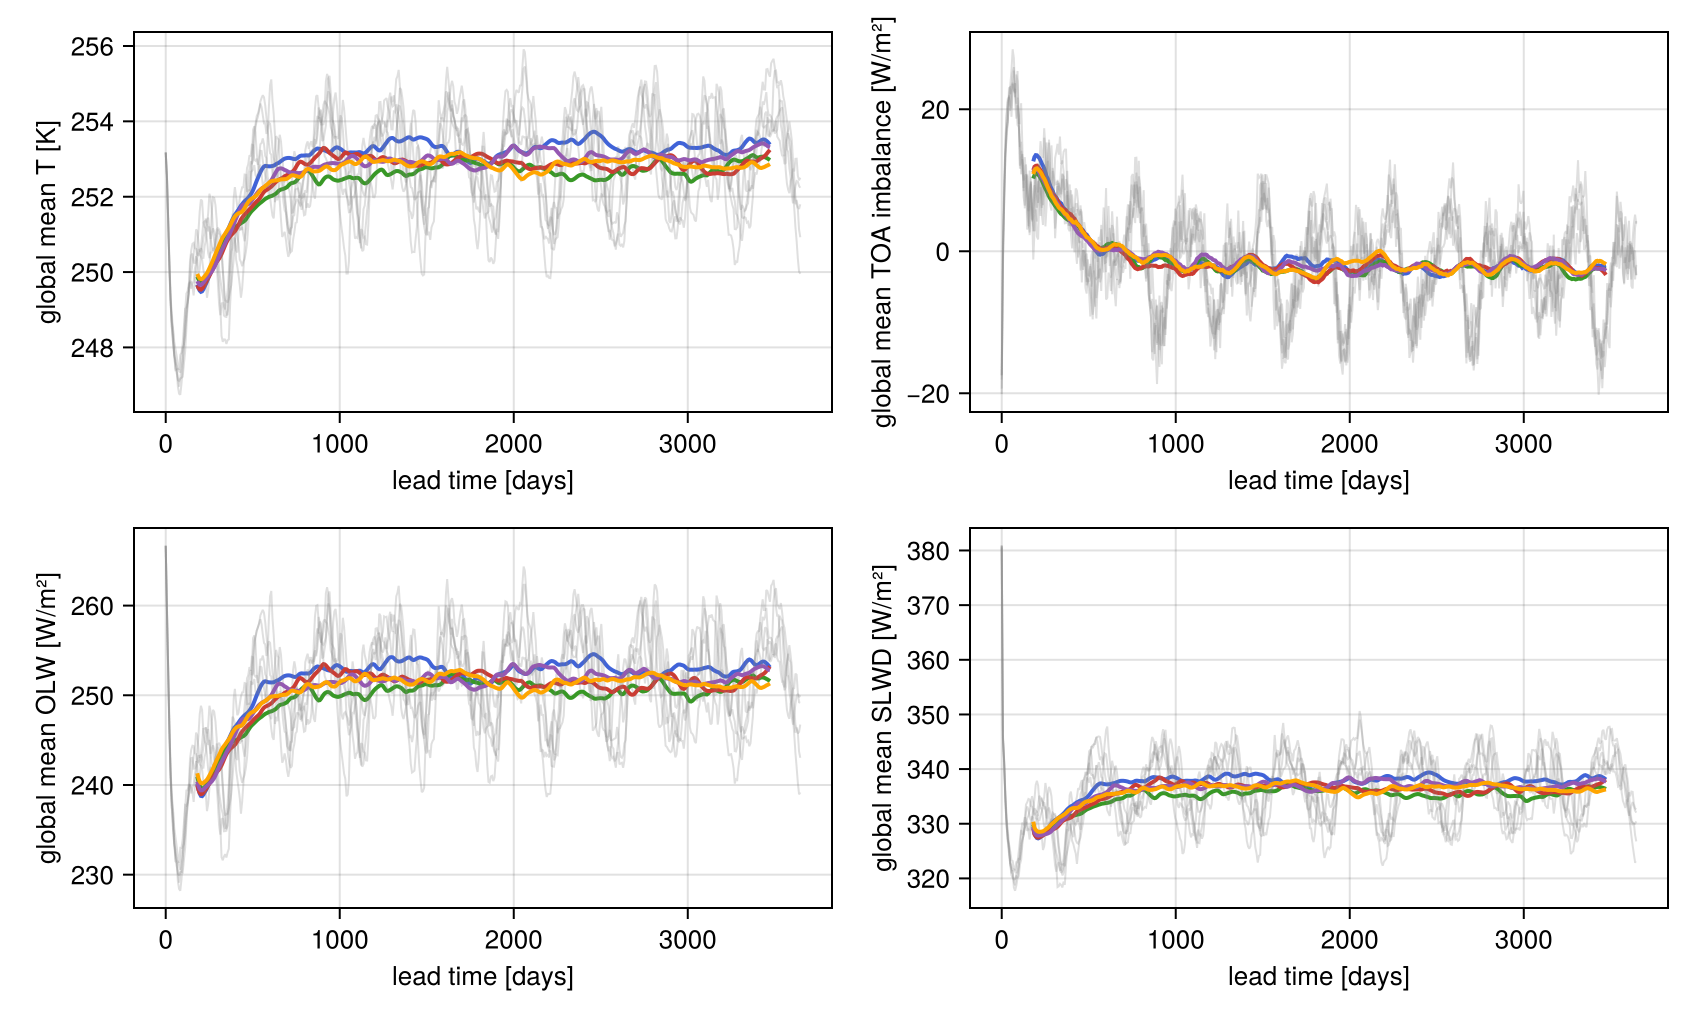

In [4]:
# Set plot parameters
smooth_days = 365

# Create plot
plot_probes(ms, (:T, :imb_TOA, :olw, :slwd); smooth_days)

## **2. RMSE Cap**

In [5]:
# RMSE distance between every pair of runs and the saturated RMSE (cap)
ds1  = load_reference("OBLW", "spinup", "distances.jld2")
caps = load_reference("OBLW", "spinup", "rmse_caps.jld2")

# Print them
for (key, cap) in pairs(caps)
    println("$(key):      \t mean = $(cap.mean), \t std = $(cap.std)")
end

T:      	 mean = 4.694887410291557, 	 std = 0.032983047432026104
olw:      	 mean = 12.156567923097665, 	 std = 0.17320884394893396
slwd:      	 mean = 17.864201884712678, 	 std = 0.13675812677279806
imb_TOA:      	 mean = 71.96305370018132, 	 std = 1.1439851853619392


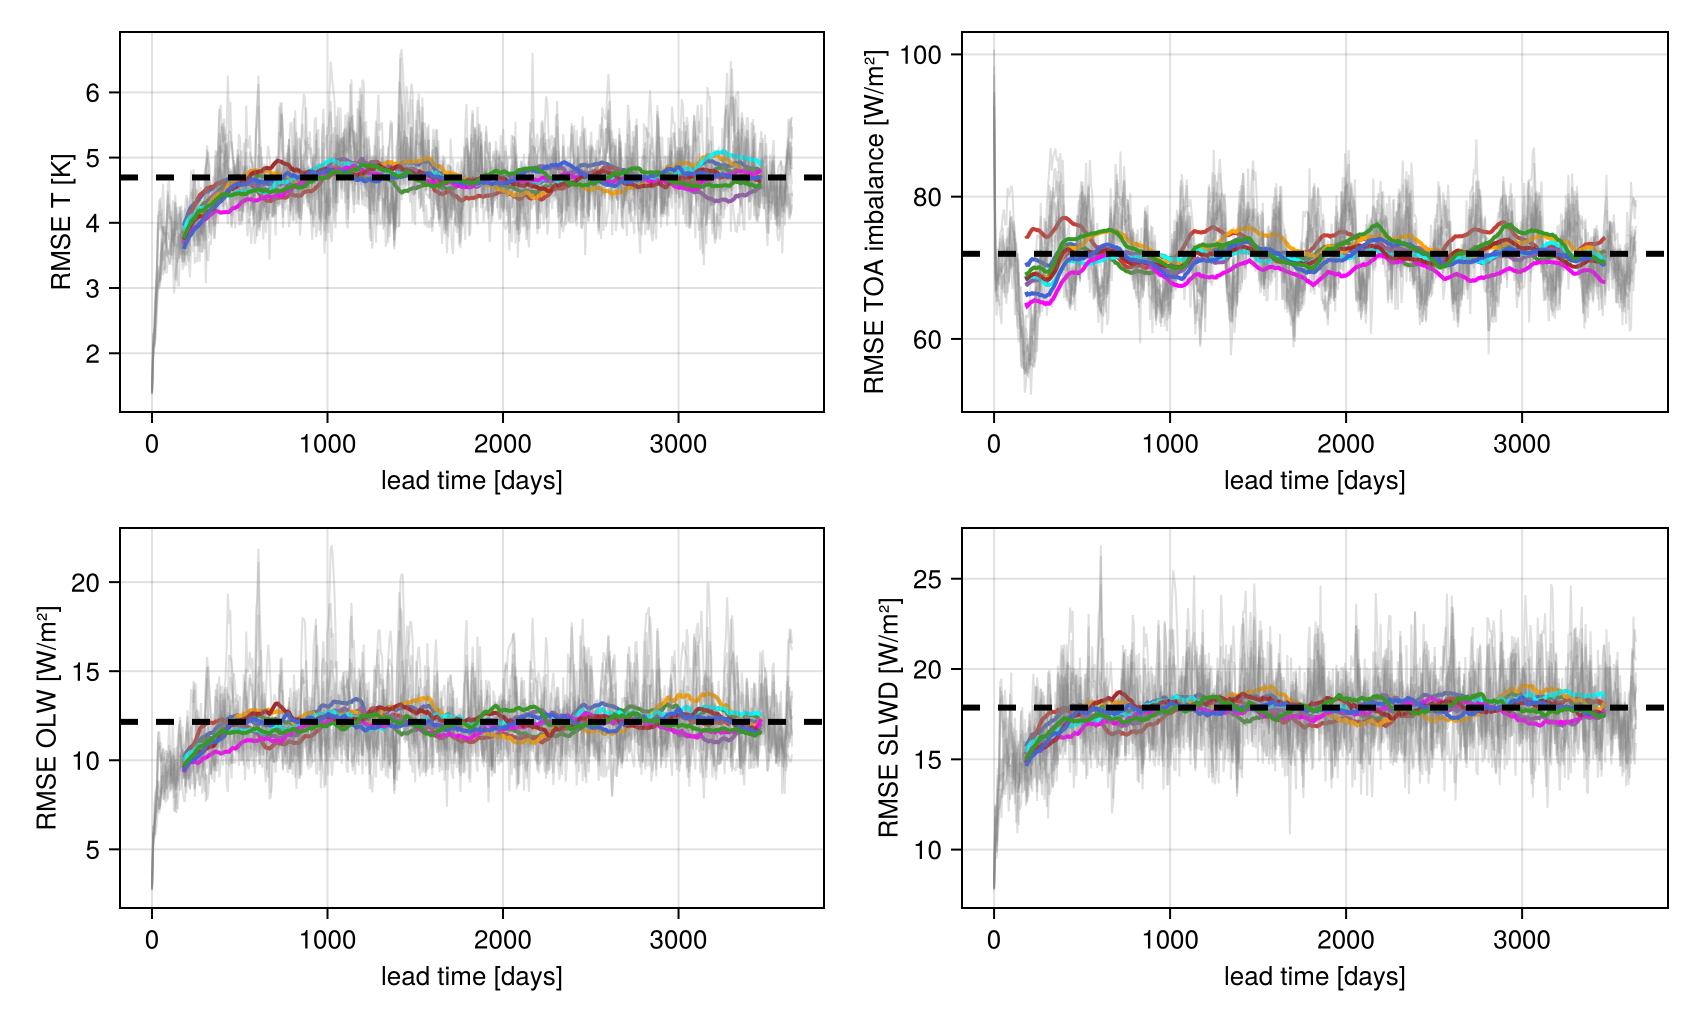

In [6]:
# Create plot
plot_probes(ds1, PROBES_SHOWN; smooth_days = 365, caps)

## **3. Error Growth: Doubling Time**

In [7]:
# RMSE distance between the trajectory pairs of every repetition (120 days)
ds3 = load_reference("OBLW", "error_growth_120days", "distances.jld2");

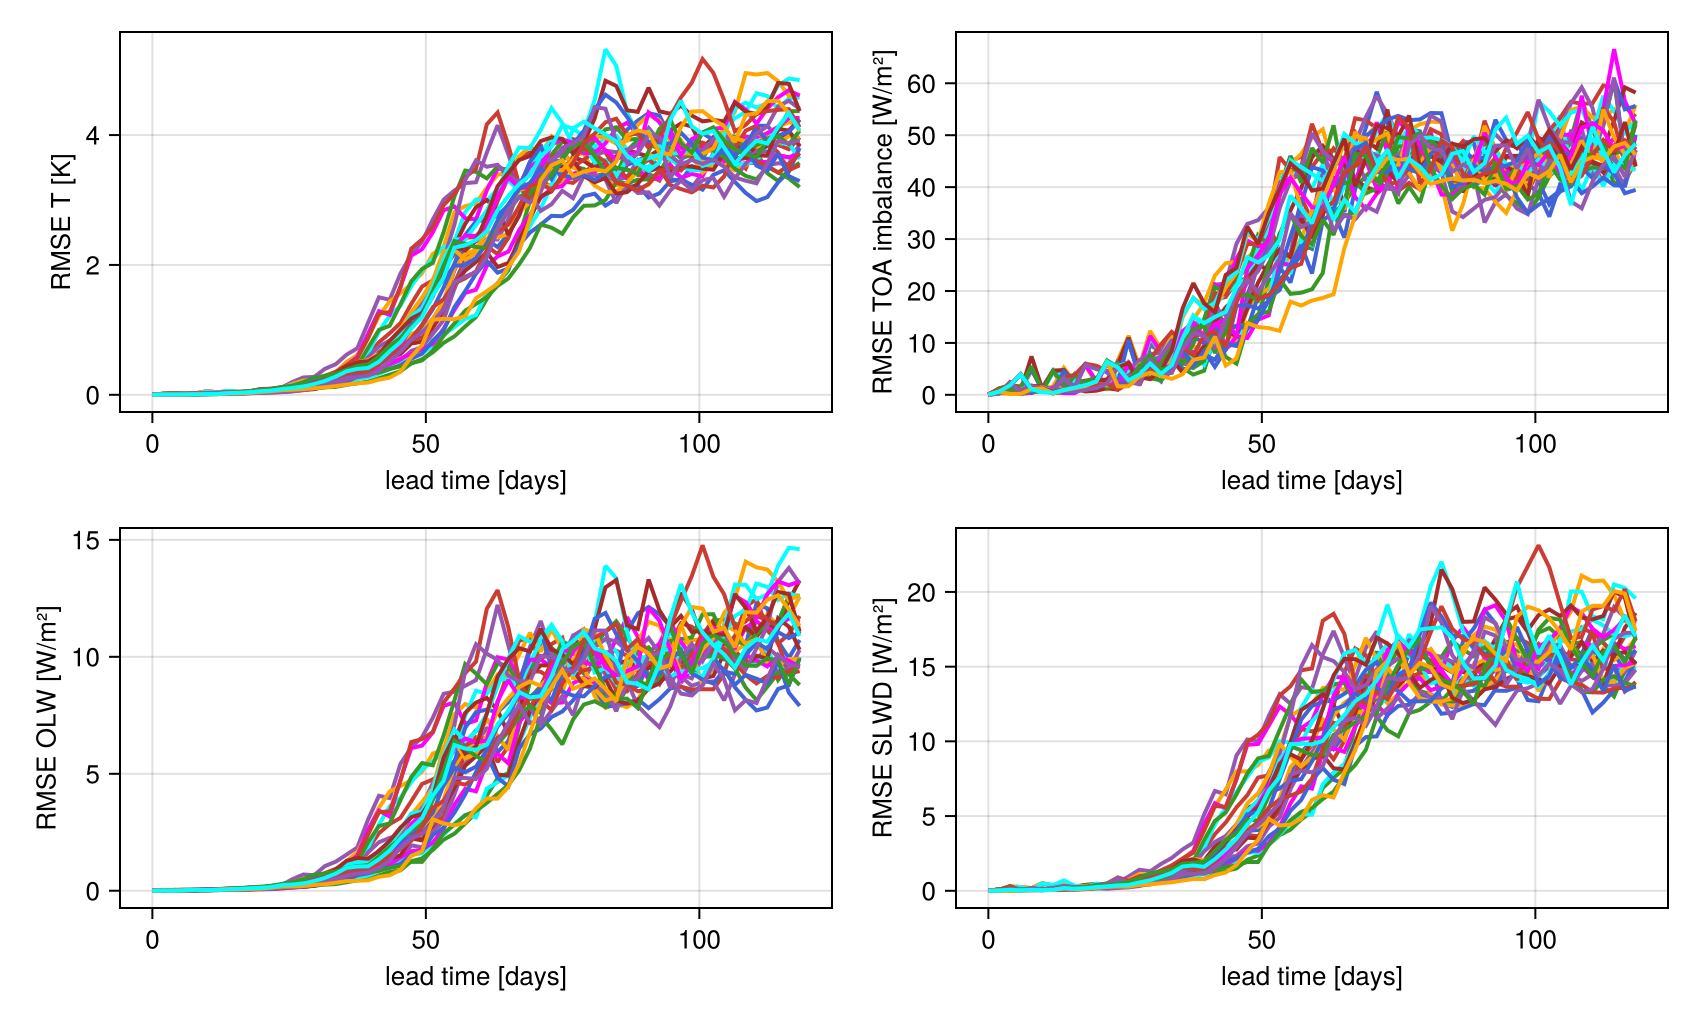

In [8]:
# Create plots
plot_probes(ds3, PROBES_SHOWN; yscale = identity)

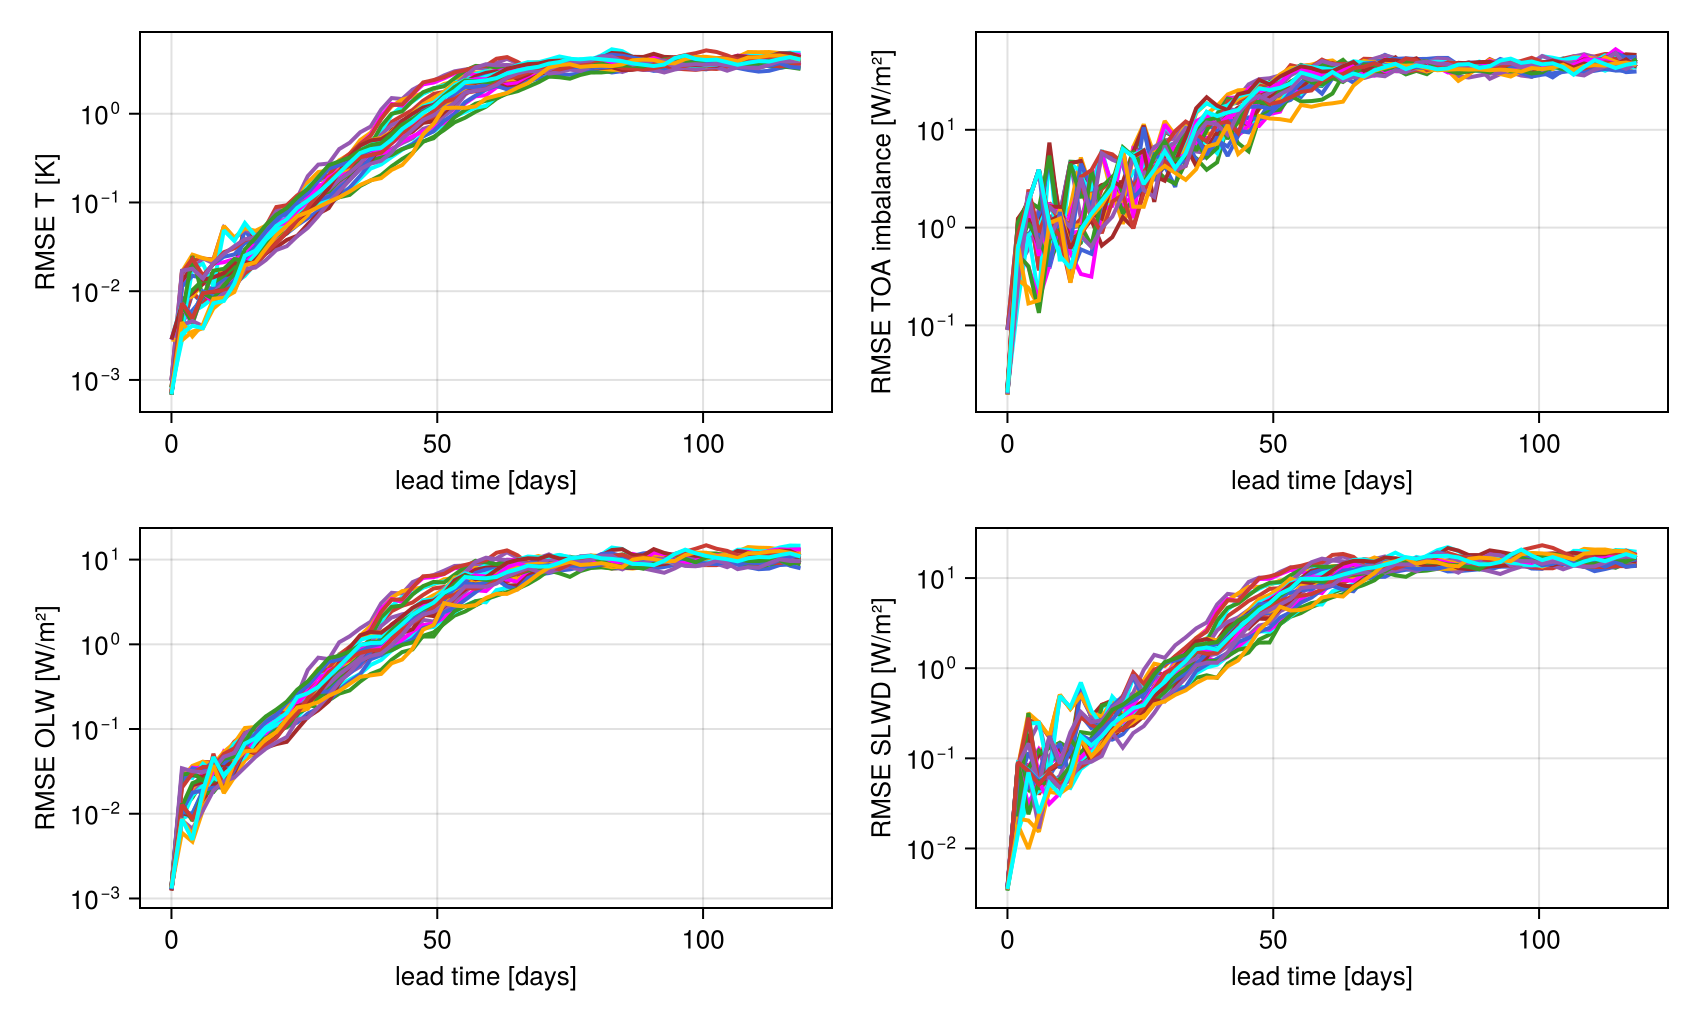

In [9]:
# Create plots
plot_probes(ds3, PROBES_SHOWN; yscale = log10)

In [10]:
# Calculate growth rate
growths = growth_rate(ds3, :T; fit_days = (14, 50))

# Doubling time
println("Doubling time / days: ")
println("Mean: \t", growths.doubling.mean)
println("Std: \t",  growths.doubling.std)

# Lyapunov exponent
println("\nLyapunov exponent / day⁻¹:")
println("Mean: \t", growths.λ.mean)
println("Std: \t",  growths.λ.std)

Doubling time / days: 
Mean: 	6.40119741035362
Std: 	0.818997087653122

Lyapunov exponent / day⁻¹:
Mean: 	0.11001489
Std: 	0.014118523
